In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("car_Dekho.csv")
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [6]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
print(data.Car_Name.value_counts())

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64


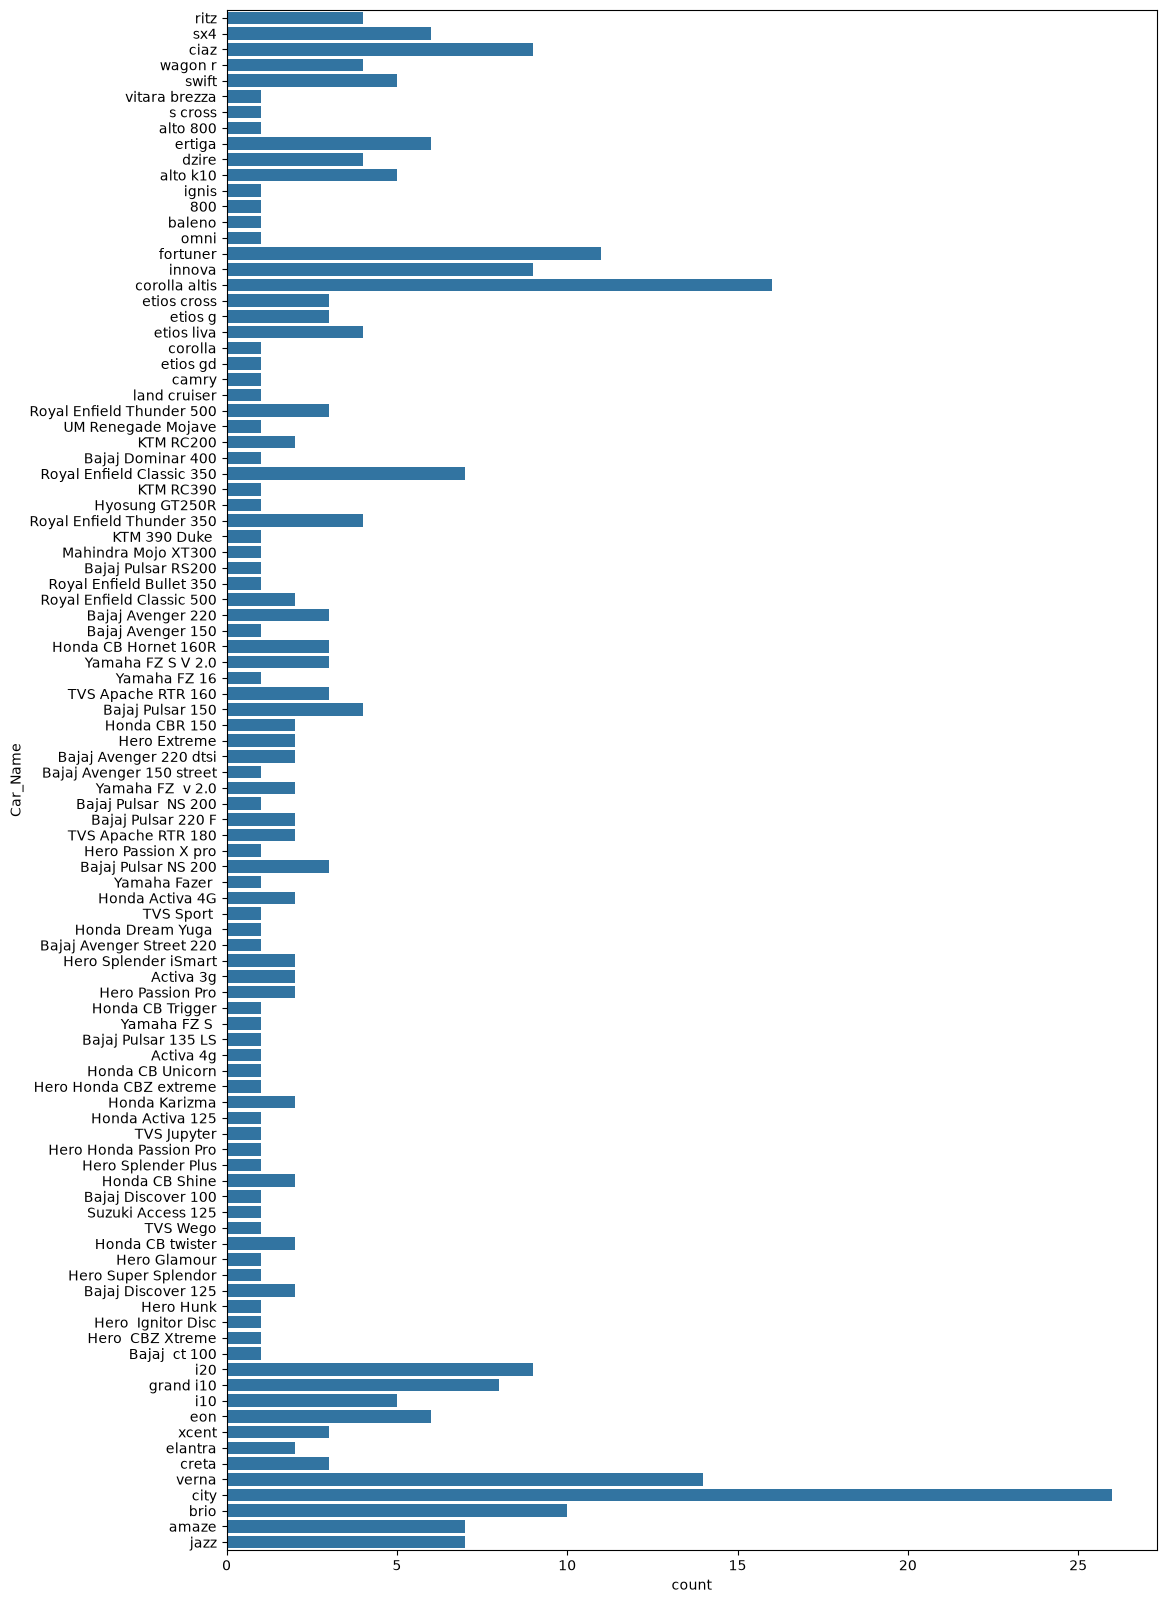

In [8]:
fig_dims = (12, 20)

fig, ax = plt.subplots(figsize=fig_dims)

sns.countplot(y='Car_Name', data=data, ax=ax)

plt.show()

In [9]:
print(data.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


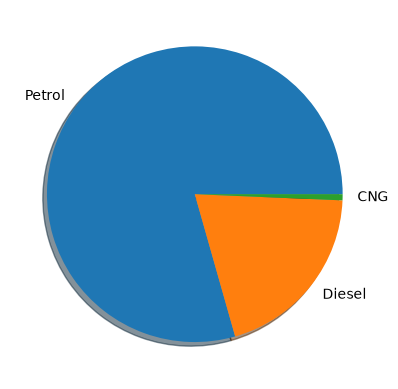

In [10]:
plt.pie(
    data.Fuel_Type.value_counts(),
    labels=['Petrol', 'Diesel', 'CNG'],
    shadow=True
)

plt.show()

<Axes: xlabel='Fuel_Type'>

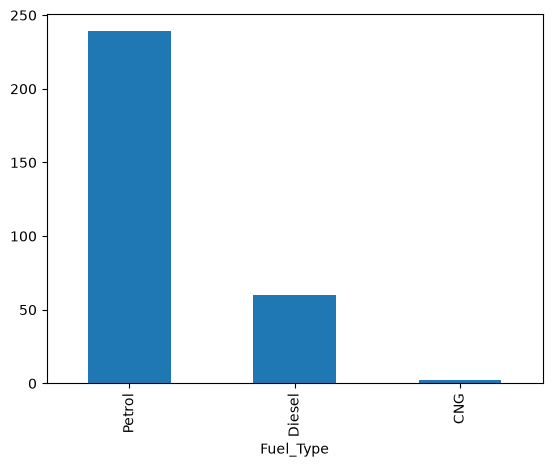

In [11]:
data.Fuel_Type.value_counts().plot.bar()

In [12]:
individual_cars = (data['Seller_Type'] == 'Individual').sum()

print("Number of vehicles sold by Individual sellers:", individual_cars)

Number of vehicles sold by Individual sellers: 106


In [13]:
automatic_cars = (data['Transmission'] == 'Automatic').sum()

print("Number of Automatic transmission vehicles:", automatic_cars)

Number of Automatic transmission vehicles: 40


In [14]:
single_owner_cars = (data['Owner'] == 1).sum()

print("Number of single owner vehicles:", single_owner_cars)

Number of single owner vehicles: 10


In [15]:
data['Depreciation'] = data['Present_Price'] - data['Selling_Price']

In [16]:
most_depreciated = data.loc[data['Depreciation'].idxmax()]

print("Most depreciated vehicle:")
print(most_depreciated[['Car_Name', 'Depreciation']])

Most depreciated vehicle:
Car_Name        land cruiser
Depreciation            57.6
Name: 86, dtype: object


In [17]:
least_depreciated = data.loc[data['Depreciation'].idxmin()]

print("Least depreciated vehicle:")
print(least_depreciated[['Car_Name', 'Depreciation']])

Least depreciated vehicle:
Car_Name        Honda Activa 4G
Depreciation               0.03
Name: 155, dtype: object


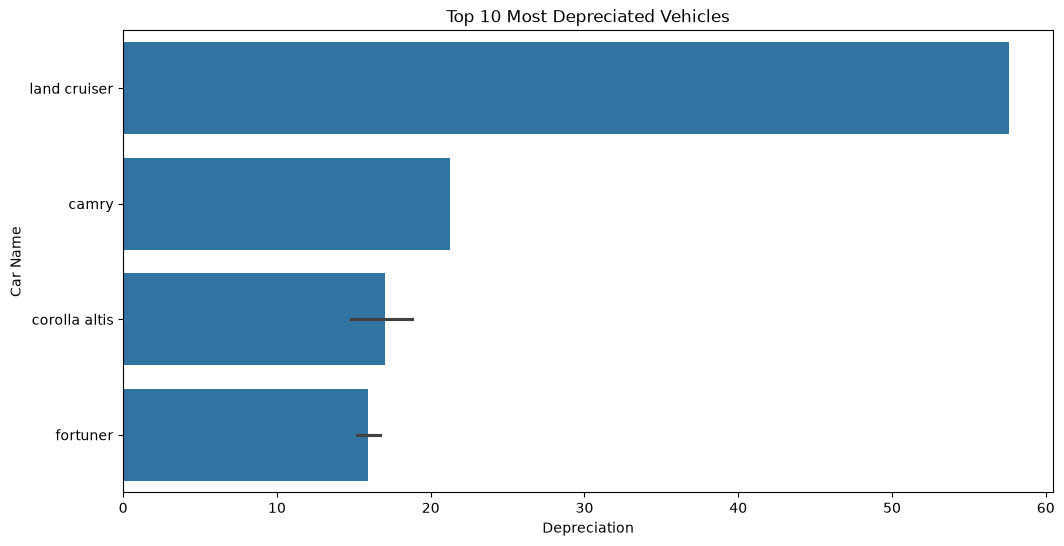

In [18]:
top_depreciation = data.nlargest(10, 'Depreciation')

plt.figure(figsize=(12, 6))
sns.barplot(x='Depreciation', y='Car_Name', data=top_depreciation)

plt.title('Top 10 Most Depreciated Vehicles')
plt.xlabel('Depreciation')
plt.ylabel('Car Name')
plt.show()

In [19]:
data['Brand'] = data['Car_Name'].str.split().str[0]

In [20]:
brand_depreciation = data.groupby('Brand')['Depreciation'].mean().sort_values()

print("Brands least affected by depreciation:")
print(brand_depreciation.head(10))

Brands least affected by depreciation:
Brand
UM          0.120000
Activa      0.183333
TVS         0.242750
Mahindra    0.250000
Yamaha      0.258750
Hero        0.265200
Honda       0.318824
Suzuki      0.330000
Bajaj       0.334400
Royal       0.423529
Name: Depreciation, dtype: float64


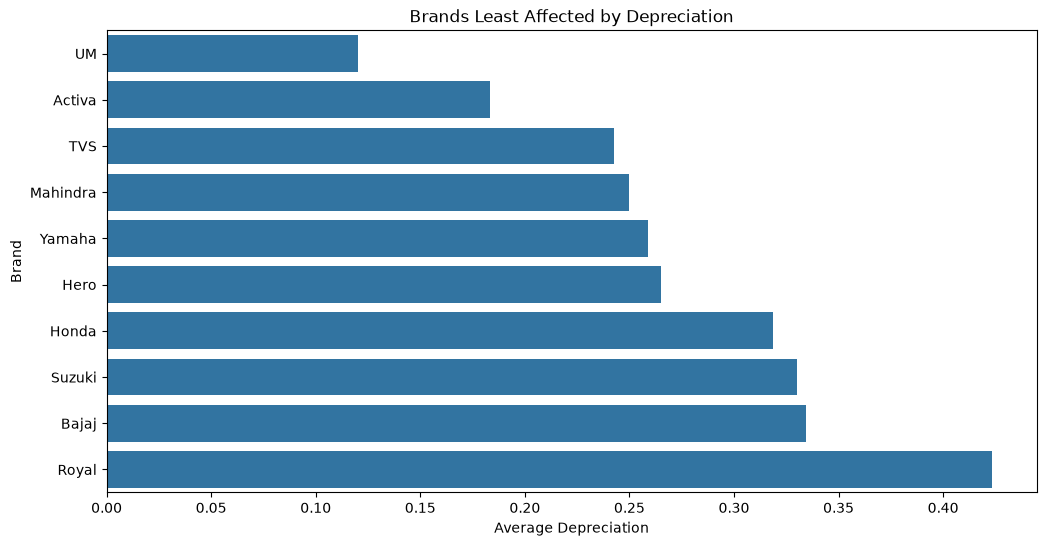

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_depreciation.head(10).values,
    y=brand_depreciation.head(10).index
)

plt.title('Brands Least Affected by Depreciation')
plt.xlabel('Average Depreciation')
plt.ylabel('Brand')
plt.show()

In [22]:
correlation = data[
    ['Year', 'Selling_Price', 'Present_Price',
     'Kms_Driven', 'Owner', 'Depreciation']
].corr()

print(correlation)

                   Year  Selling_Price  Present_Price  Kms_Driven     Owner  \
Year           1.000000       0.236141      -0.047584   -0.524342 -0.182104   
Selling_Price  0.236141       1.000000       0.878983    0.029187 -0.088344   
Present_Price -0.047584       0.878983       1.000000    0.203647  0.008057   
Kms_Driven    -0.524342       0.029187       0.203647    1.000000  0.089216   
Owner         -0.182104      -0.088344       0.008057    0.089216  1.000000   
Depreciation  -0.333746       0.520881       0.864902    0.333832  0.107415   

               Depreciation  
Year              -0.333746  
Selling_Price      0.520881  
Present_Price      0.864902  
Kms_Driven         0.333832  
Owner              0.107415  
Depreciation       1.000000  


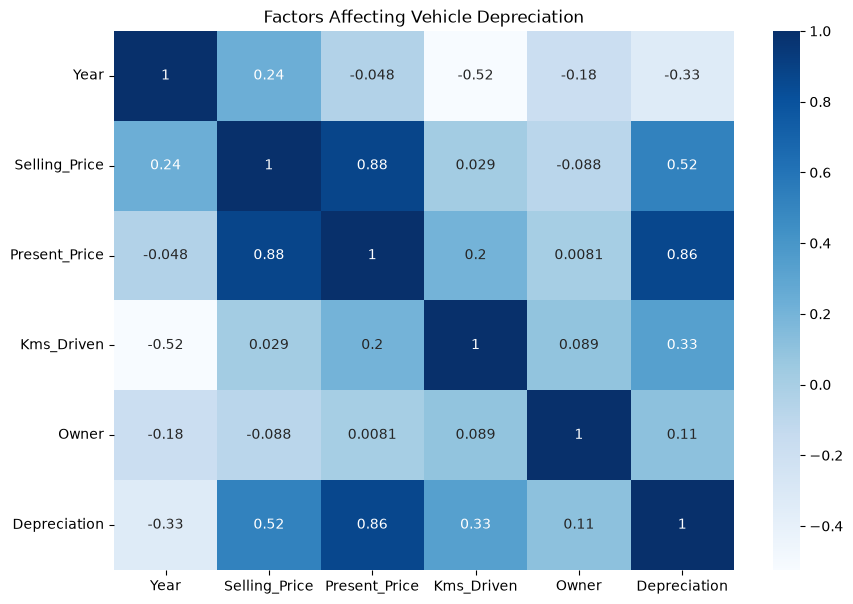

In [23]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title('Factors Affecting Vehicle Depreciation')
plt.show()

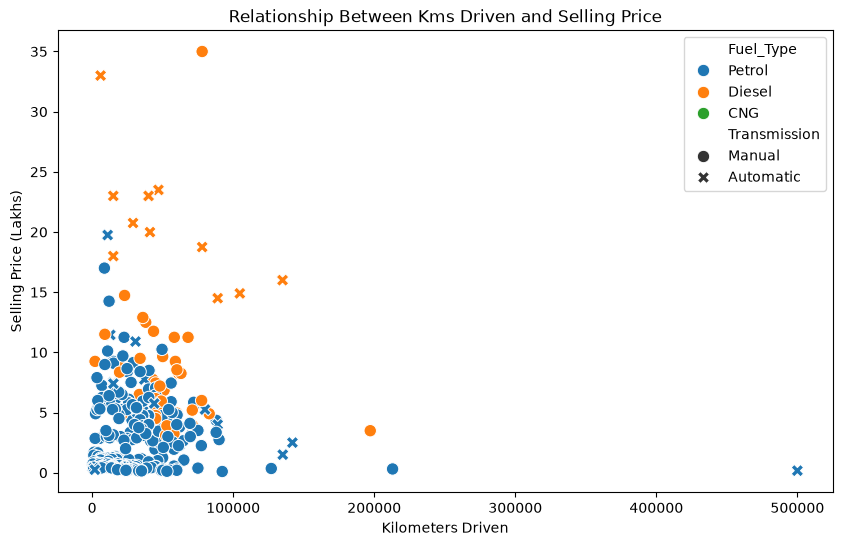

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Kms_Driven',
    y='Selling_Price',
    hue='Fuel_Type',
    style='Transmission',
    s=80
)

plt.title('Relationship Between Kms Driven and Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.show()